# Clase 7: APIs + LLMs
## YouTube, Hugging Face y Google Trends — Mundial 2026

En esta clase vamos a construir un pipeline completo de análisis de texto en tres partes:

1. **YouTube Data API** — descargar comentarios del video México vs Ecuador
2. **Hugging Face** — clasificar esos comentarios automáticamente con un LLM
3. **Google Trends** — ver si el Mundial cambió los patrones de búsqueda en México

Lo más importante de la clase: el flujo **autenticarse → pedir datos → parsear → analizar** es el mismo para las tres APIs. Una vez que lo aprendes con una, lo puedes aplicar a cualquier otra.

---
## Paso 0 — Instalación

Instalamos todas las librerías que vamos a necesitar. `%%capture` suprime el output de pip para no inundar la pantalla.

In [1]:
%%capture
pip install google-api-python-client transformers torch pandas matplotlib pytrends

---
## Paso 1 — Imports y configuración

### GPU vs CPU

El modelo de clasificación puede correr en:
- **GPU** — procesa todo en paralelo, clasifica 200 comentarios en segundos
- **CPU** — procesa uno a uno, puede tardar ~3 minutos para 200 comentarios

Colab da GPU gratis pero tiene cuota diaria. La celda de abajo detecta automáticamente si hay GPU disponible y elige el dispositivo correcto — no tienes que cambiar nada a mano.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import time
from google.colab import userdata
from googleapiclient.discovery import build
from transformers import pipeline

# torch.cuda.is_available() devuelve True si hay GPU disponible
# guardamos el resultado en DEVICE para usarlo más adelante
# device=0  → primera GPU disponible
# device=-1 → CPU

if torch.cuda.is_available():
    DEVICE = 0
    print(f"✓ GPU disponible: {torch.cuda.get_device_name(0)}")
    print("  El modelo correrá en GPU — clasificación rápida")
else:
    DEVICE = -1
    print("⚠ Sin GPU — usando CPU")
    print("  Puede tardar ~3 minutos para 200 comentarios")
    print("  Para activar GPU: Runtime → Change runtime type → T4 GPU")

✓ GPU disponible: Tesla T4
  El modelo correrá en GPU — clasificación rápida


---
## Paso 2 — API keys

Las keys son contraseñas para acceder a las APIs. Nunca las ponemos directamente en el código porque si subimos el notebook a GitHub cualquiera puede verlas y usarlas.

En Colab las guardamos en **Secrets** (ícono 🔑 en la barra izquierda):
1. Clic en 🔑 → **Add new secret**
2. Name: `YOUTUBE_API_KEY` → Value: tu key de Google Cloud
3. Activa el toggle **Notebook access**

Para conseguir la key de YouTube:
1. Ve a [console.cloud.google.com](https://console.cloud.google.com)
2. Crea un proyecto → **APIs y servicios → Biblioteca → YouTube Data API v3 → Habilitar**
3. **Credenciales → Crear credenciales → Clave de API**

In [3]:
# userdata.get('nombre') lee el Secret con ese nombre exacto
# si el nombre no coincide exactamente devuelve None
YOUTUBE_API_KEY = userdata.get('YOUTUBE_API_KEY')

# el ID del video está en la URL después de ?v=
# https://www.youtube.com/watch?v=iCFwyDKzihA
#                                  ↑ este es el ID
VIDEO_ID = "iCFwyDKzihA"   # México vs Ecuador, Mundial 2026

print("Key cargada ✓")

Key cargada ✓


---
## Paso 3 — YouTube Data API

### ¿Qué es una API?

Cuando entras a YouTube en el navegador, el servidor te manda HTML — código que el navegador convierte en la página visual. Eso es difícil de leer desde Python.

Una **API** es un canal distinto que el mismo servidor ofrece para dar datos estructurados directamente a programas. En vez de HTML, devuelve **JSON** — un formato de texto organizado en pares `clave: valor` que Python puede leer fácilmente.

El flujo siempre es el mismo:
```
1. Construir la petición  →  qué quiero y con qué parámetros
2. Ejecutar la petición   →  mandarla al servidor de Google
3. Parsear la respuesta   →  navegar el JSON y extraer los datos
```

In [4]:
# build() crea el cliente — el objeto que nos permite hablar con la API
# 'youtube' = nombre del servicio de Google
# 'v3'      = versión de la API (siempre usar la más reciente)
# developerKey = nuestra key para que Google sepa quién pregunta

youtube = build('youtube', 'v3', developerKey=YOUTUBE_API_KEY)
print("Cliente de YouTube creado ✓")

Cliente de YouTube creado ✓


In [5]:
# Antes de escribir la función completa, veamos cómo se ve
# la respuesta cruda de la API con solo 2 comentarios
# Así entendemos la estructura del JSON antes de procesarlo

# paso 1: construir la petición
peticion_prueba = youtube.commentThreads().list(
    part       = 'snippet',  # 'snippet' = queremos el contenido
                              # sin esto la API no sabe qué información darte
    videoId    = VIDEO_ID,
    maxResults = 2            # solo 2 para ver la estructura
)

# paso 2: ejecutar — aquí es cuando realmente llamamos a Google
# hasta este momento solo construimos la petición, no la enviamos
respuesta_prueba = peticion_prueba.execute()

# paso 3: explorar la estructura del JSON
# la respuesta es un diccionario anidado — hay que navegar niveles
print("Nivel 1 — Claves del JSON raíz:")
print(list(respuesta_prueba.keys()))
# 'items' es la lista de comentarios — lo que nos interesa

print("\nNivel 2 — Claves de items[0]:")
print(list(respuesta_prueba['items'][0].keys()))
# 'snippet' tiene el contenido del hilo de comentarios

print("\nTexto del primer comentario (navegando 4 niveles):")
# items[0] → snippet → topLevelComment → snippet → textDisplay
print(respuesta_prueba['items'][0]['snippet']['topLevelComment']['snippet']['textDisplay'])

Nivel 1 — Claves del JSON raíz:
['kind', 'etag', 'nextPageToken', 'pageInfo', 'items']

Nivel 2 — Claves de items[0]:
['kind', 'etag', 'id', 'snippet']

Texto del primer comentario (navegando 4 niveles):
Dónde están los ecuatorianas? 😂😂Perdón los ecuatorianos solo sirvieron para llorar y buscar pretextos para disimular la vergüenza de su disque mejor defensa del mundo , cuando un morro de 17 años los hizo mierda, viva México p.... 🇲🇽💯


In [6]:
def descargar_comentarios(video_id, max_comentarios=200):
    """
    Descarga comentarios de un video de YouTube.

    YouTube no manda todos los comentarios de una vez — los divide en páginas
    de máximo 100. Esta función maneja esa paginación automáticamente.
    """
    comentarios = []    # lista vacía donde acumulamos los resultados
    page_token  = None  # None = primera página
                        # YouTube nos da el token para la siguiente página

    # el while corre hasta que tengamos suficientes comentarios
    while len(comentarios) < max_comentarios:

        peticion = youtube.commentThreads().list(
            part       = 'snippet',
            videoId    = video_id,
            # min() para no pedir más de los que necesitamos en la última página
            maxResults = min(100, max_comentarios - len(comentarios)),
            order      = 'relevance',  # los más relevantes primero
            pageToken  = page_token    # None en la primera vuelta, token después
        )
        respuesta = peticion.execute()

        # iteramos sobre los comentarios de esta página
        for item in respuesta['items']:
            # navegamos la estructura anidada hasta llegar a los datos
            snippet = item['snippet']['topLevelComment']['snippet']
            comentarios.append({
                'texto'     : snippet['textDisplay'],
                'autor'     : snippet['authorDisplayName'],
                'likes'     : snippet['likeCount'],
                'fecha'     : snippet['publishedAt'],
                'respuestas': item['snippet']['totalReplyCount']
            })

        # .get() devuelve None si la clave no existe — más seguro que ['clave']
        # si no hay nextPageToken, llegamos a la última página y salimos
        page_token = respuesta.get('nextPageToken')
        if not page_token:
            break

    print(f"Descargados {len(comentarios)} comentarios ✓")
    return comentarios


comentarios_raw = descargar_comentarios(VIDEO_ID, max_comentarios=2000)

Descargados 1042 comentarios ✓


---
## Paso 4 — Limpiar con pandas

`pandas` es la librería de manipulación de datos de Python. Su estructura central es el **DataFrame** — una tabla con filas y columnas, igual que el data frame de R. La mayoría de las operaciones de tidyverse tienen un equivalente en pandas.

In [7]:
# pd.DataFrame() convierte la lista de diccionarios en una tabla
# cada diccionario → una fila
# las claves del diccionario → las columnas
# equivale a tibble() en R

df = pd.DataFrame(comentarios_raw)
print(f"Dimensiones: {df.shape}")   # (filas, columnas) — equivale a dim() en R
df.head()

Dimensiones: (1042, 5)


,texto,autor,likes,fecha,respuestas
0,Mexicanos es un honor presenciar esto con uste...,@AngelMãløt3,6145,2026-07-01T04:16:00Z,60
1,"Después de todo lo que paso Raúl Jiménez, verl...",@jbomts,4269,2026-07-01T04:12:17Z,35
2,"A mis 75 años, veo a la selección de mi México...",@marioeusebiobenitez746,1429,2026-07-01T11:28:25Z,26
3,Un chico de 17 años que juega en Xolos de Tiju...,@Christian-qg6yq,2954,2026-07-01T04:27:02Z,42
4,"A celebrar Pero mañana... Cabeza fría, humilda...",@SenorX-bn4wt,1333,2026-07-01T04:50:02Z,6


In [8]:
# dtypes muestra el tipo de cada columna — equivale a glimpse() en R
# object = texto (string)
# int64  = entero
df.dtypes

,0
texto,object
autor,object
likes,int64
fecha,object
respuestas,int64


In [9]:
# ── Limpieza en tres pasos ────────────────────────────────────────────────────

# 1. Fecha: de texto a datetime
#    viene como '2026-06-30T22:15:03.000Z' — texto, no fecha
#    pd.to_datetime() lo convierte a tipo fecha que pandas entiende
#    equivale a as.Date() en R
df['fecha'] = pd.to_datetime(df['fecha'])

# 2. Texto: YouTube mete tags HTML dentro de los comentarios
#    <br> = salto de línea, &amp; = símbolo &, &#39; = comilla apostrofe
#    .str.replace() aplica el reemplazo a toda la columna a la vez
#    equivale a str_replace() en R
df['texto_limpio'] = (
    df['texto']
    .str.replace('<br>', ' ', regex=False)
    .str.replace('&amp;', '&', regex=False)
    .str.replace('&#39;', "'", regex=False)
    .str.strip()   # quitar espacios al inicio y al final
)

# 3. Filtrar comentarios muy cortos
#    comentarios de menos de 15 caracteres ('jajaja', 'gg', '🇲🇽')
#    no aportan información útil para clasificar
#    df[condicion] filtra filas donde la condicion es True — equivale a filter() en R
#    .reset_index(drop=True) reordena los índices después de filtrar
#    (sin esto quedarían con huecos: 0, 3, 7, 12...)
df = df[df['texto_limpio'].str.len() >= 15].reset_index(drop=True)

print(f"Comentarios después de limpiar: {len(df)}")
df[['texto_limpio', 'likes', 'respuestas']].head(8)

Comentarios después de limpiar: 976


,texto_limpio,likes,respuestas
0,Mexicanos es un honor presenciar esto con uste...,6145,60
1,"Después de todo lo que paso Raúl Jiménez, verl...",4269,35
2,"A mis 75 años, veo a la selección de mi México...",1429,26
3,Un chico de 17 años que juega en Xolos de Tiju...,2954,42
4,"A celebrar Pero mañana... Cabeza fría, humilda...",1333,6
5,Fue un partido muy bonito porque mi Papá tiene...,473,11
6,Quiñones eres un bendito orgullo nacional,4286,64
7,QUE JUEGAZO SE MANDO GILBERTO MORA 🔥❤️ un orgu...,2146,47


In [10]:
# Exploración rápida antes de clasificar
# .describe() da estadísticos de la columna — equivale a summary() en R
print("Estadísticas de likes:")
print(df['likes'].describe())

print(f"\nComentario con más likes:")
# .idxmax() devuelve el ÍNDICE de la fila con el valor máximo
# .loc[índice, columna] accede a una celda específica
idx_max = df['likes'].idxmax()
print(f"'{df.loc[idx_max, 'texto_limpio']}' ({df.loc[idx_max, 'likes']} likes)")

Estadísticas de likes:
count     976.000000
mean       41.525615
std       323.648831
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max      6145.000000
Name: likes, dtype: float64

Comentario con más likes:
'Mexicanos es un honor presenciar esto con ustedes hermanos viva México alv' (6145 likes)


---
## Paso 5 — Zero-Shot Classification

### ¿Qué es zero-shot?

Un clasificador tradicional necesita **miles de comentarios etiquetados a mano** para entrenarse — alguien tiene que leer cada uno y escribir si es celebración, crítica o burla. Solo entonces el modelo puede aprender.

**Zero-shot** significa cero ejemplos etiquetados, cero entrenamiento. Le decimos las categorías en el momento y el modelo usa su comprensión del lenguaje para decidir.

### ¿Qué modelo usamos?

Usamos `MoritzLaurer/mDeBERTa-v3-base-mnli-xnli` — un modelo multilingüe entrenado en NLI (Natural Language Inference). NLI es la tarea de decidir si una hipótesis se sigue de un texto. Zero-shot usa eso reformulando cada categoría como hipótesis:

> Texto: *"jajaja Ecuador se fue a llorar"*  
> Hipótesis: *"Este comentario corresponde a la categoría de burla al equipo perdedor"*  
> ¿Verdadero o falso?

Al ser **multilingüe**, este modelo funciona bien con texto en español directamente — a diferencia de `bart-large-mnli` que fue entrenado principalmente en inglés.

### Categorías en español

Como el modelo es multilingüe, podemos usar categorías directamente en español.

In [11]:
# pipeline() empaqueta todo lo que necesita el modelo:
# tokenizador (convierte texto a números) + modelo + post-procesamiento
# 'zero-shot-classification' = tipo de tarea
# device = DEVICE → GPU si está disponible, CPU si no

print(f"Cargando modelo en {'GPU' if DEVICE == 0 else 'CPU'}...")
print("(tarda ~1 minuto la primera vez — descarga el modelo de Hugging Face)")

clasificador = pipeline(
    "zero-shot-classification",
    model  = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    device = DEVICE
)

print("Modelo listo ✓")

Cargando modelo en GPU...
(tarda ~1 minuto la primera vez — descarga el modelo de Hugging Face)


config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

Modelo listo ✓


In [12]:
# Las categorías en las que vamos a clasificar los comentarios
# Al ser un modelo multilingüe, las categorías pueden estar en español
CATEGORIAS = [
    "celebración de la victoria",
    "burla al equipo perdedor",
    "crítica al rendimiento"
]

In [13]:
# Primero testeamos con UN solo comentario para entender
# qué devuelve el modelo antes de procesar todos

comentario_prueba = "Que felicidad, no puedo creer que por fin ganamos 🇲🇽"

# clasificador() recibe el texto y las categorías
# hypothesis_template es la plantilla que usa el modelo para reformular
# cada categoría como hipótesis NLI
resultado = clasificador(
    comentario_prueba,
    CATEGORIAS,
    hypothesis_template = "Este comentario corresponde a la categoría de {}."
)

# el resultado es un diccionario con:
# 'sequence' = el texto original
# 'labels'   = lista de categorías ordenada de mayor a menor score
# 'scores'   = lista de scores en el mismo orden (suman ~1)
print("Estructura del resultado:")
print(f"  Claves: {list(resultado.keys())}")
print(f"\nTexto: '{comentario_prueba}'")
print("\nScores por categoría (de mayor a menor):")
for label, score in zip(resultado['labels'], resultado['scores']):
    barra = '█' * int(score * 30)
    print(f"  {label:<35} {score:.3f}  {barra}")
print(f"\n→ Categoría asignada: {resultado['labels'][0]}")

Estructura del resultado:
  Claves: ['sequence', 'labels', 'scores']

Texto: 'Que felicidad, no puedo creer que por fin ganamos 🇲🇽'

Scores por categoría (de mayor a menor):
  celebración de la victoria          0.744  ██████████████████████
  crítica al rendimiento              0.255  ███████
  burla al equipo perdedor            0.001  

→ Categoría asignada: celebración de la victoria


In [14]:
# Ahora probamos con 4 comentarios de tipos distintos
# para verificar que el modelo funciona bien antes del loop completo

comentarios_test = [
    "Que felicidad, no puedo creer que por fin ganamos",
    "Ecuador jugó muy mal en el segundo tiempo, la presión alta de México funcionó",
    "jajajaja son una broma los de Ecuador, no sé cómo llegaron hasta este punto",
    "El gol de Jiménez fue increíble pero la defensa todavía me preocupa"
]

print("Test comentario por comentario:\n")
for j, comentario in enumerate(comentarios_test):
    resultado = clasificador(
        comentario,
        CATEGORIAS,
        hypothesis_template = "Este comentario corresponde a la categoría de {}."
    )
    print(f"── Comentario {j+1} ──")
    print(f"Texto:     '{comentario}'")
    # resultado['labels'][0] = categoría con mayor score
    # resultado['scores'][0] = su nivel de confianza (0 a 1)
    print(f"Categoría: {resultado['labels'][0]} (score: {resultado['scores'][0]:.3f})")
    print()

Test comentario por comentario:

── Comentario 1 ──
Texto:     'Que felicidad, no puedo creer que por fin ganamos'
Categoría: celebración de la victoria (score: 0.766)

── Comentario 2 ──
Texto:     'Ecuador jugó muy mal en el segundo tiempo, la presión alta de México funcionó'
Categoría: crítica al rendimiento (score: 0.994)

── Comentario 3 ──
Texto:     'jajajaja son una broma los de Ecuador, no sé cómo llegaron hasta este punto'
Categoría: burla al equipo perdedor (score: 0.481)

── Comentario 4 ──
Texto:     'El gol de Jiménez fue increíble pero la defensa todavía me preocupa'
Categoría: crítica al rendimiento (score: 0.978)



---
## Paso 6 — Clasificar todos los comentarios

In [18]:
N          = min(2000, len(df))
df_muestra = df.head(N).copy()   # .copy() para no modificar el DataFrame original
                                  # sin .copy(), modificar df_muestra modificaría df

categorias_asignadas = []   # listas vacías donde acumulamos los resultados
scores_asignados     = []

print(f"Clasificando {N} comentarios en {'GPU' if DEVICE == 0 else 'CPU'}...")
if DEVICE == -1:
    print("(en CPU puede tardar ~3 minutos)")
print()

# enumerate(serie) devuelve pares (índice, valor)
# i = número de fila, texto = contenido de la celda
for i, texto in enumerate(df_muestra['texto_limpio']):

    resultado = clasificador(
        texto,
        CATEGORIAS,
        hypothesis_template = "Este comentario corresponde a la categoría de {}."
    )

    # .append() agrega un elemento al final de la lista
    # equivale a c(lista, nuevo_elemento) en R
    categorias_asignadas.append(resultado['labels'][0])
    scores_asignados.append(resultado['scores'][0])

    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{N} procesados...")

# agregar las dos columnas nuevas al DataFrame
# df['nueva_columna'] = lista → equivale a mutate() en R
df_muestra['categoria'] = categorias_asignadas
df_muestra['score']     = scores_asignados

print(f"\n¡Listo! {N} comentarios clasificados ✓")
df_muestra[['texto_limpio', 'categoria', 'score']].head(10)

Clasificando 976 comentarios en GPU...

  20/976 procesados...
  40/976 procesados...
  60/976 procesados...
  80/976 procesados...
  100/976 procesados...
  120/976 procesados...
  140/976 procesados...
  160/976 procesados...
  180/976 procesados...
  200/976 procesados...
  220/976 procesados...
  240/976 procesados...
  260/976 procesados...
  280/976 procesados...
  300/976 procesados...
  320/976 procesados...
  340/976 procesados...
  360/976 procesados...
  380/976 procesados...
  400/976 procesados...
  420/976 procesados...
  440/976 procesados...
  460/976 procesados...
  480/976 procesados...
  500/976 procesados...
  520/976 procesados...
  540/976 procesados...
  560/976 procesados...
  580/976 procesados...
  600/976 procesados...
  620/976 procesados...
  640/976 procesados...
  660/976 procesados...
  680/976 procesados...
  700/976 procesados...
  720/976 procesados...
  740/976 procesados...
  760/976 procesados...
  780/976 procesados...
  800/976 procesados...
  82

,texto_limpio,categoria,score
0,Mexicanos es un honor presenciar esto con uste...,celebración de la victoria,0.879135
1,"Después de todo lo que paso Raúl Jiménez, verl...",crítica al rendimiento,0.990650
2,"A mis 75 años, veo a la selección de mi México...",celebración de la victoria,0.688421
3,Un chico de 17 años que juega en Xolos de Tiju...,celebración de la victoria,0.838506
4,"A celebrar Pero mañana... Cabeza fría, humilda...",crítica al rendimiento,0.994517
5,Fue un partido muy bonito porque mi Papá tiene...,celebración de la victoria,0.742563
6,Quiñones eres un bendito orgullo nacional,celebración de la victoria,0.958677
7,QUE JUEGAZO SE MANDO GILBERTO MORA 🔥❤️ un orgu...,celebración de la victoria,0.931719
8,"Qué les costaba jugar así ,años sin ver esta ...",crítica al rendimiento,0.980306
9,"Grande México, grande mi país cerrando las boc...",crítica al rendimiento,0.528820


---
## Paso 7 — Análisis y visualización

In [21]:
# .value_counts() cuenta cuántos hay de cada valor único
# equivale a count() en tidyverse
conteo = df_muestra['categoria'].value_counts()
print("Comentarios por categoría:")
print(conteo)
print("\nPorcentajes:")
print((conteo / len(df_muestra) * 100).round(1))

Comentarios por categoría:
categoria
crítica al rendimiento        779
celebración de la victoria    183
burla al equipo perdedor       14
Name: count, dtype: int64

Porcentajes:
categoria
crítica al rendimiento        79.8
celebración de la victoria    18.8
burla al equipo perdedor       1.4
Name: count, dtype: float64


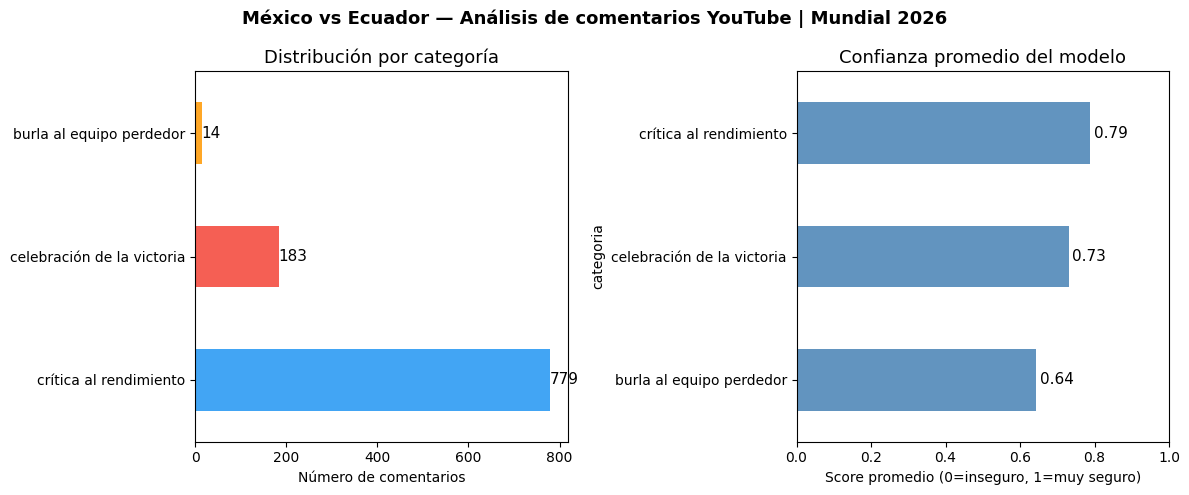

In [22]:
# plt.subplots(1, 2) crea una figura con 1 fila y 2 columnas de paneles
# axes[0] = panel izquierdo, axes[1] = panel derecho
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colores = ['#2196F3', '#F44336', '#FF9800']

# ── Panel izquierdo: cuántos comentarios hay de cada categoría ────────────────
conteo.plot(kind='barh', ax=axes[0], color=colores, alpha=0.85)
axes[0].set_title('Distribución por categoría', fontsize=13)
axes[0].set_xlabel('Número de comentarios')
axes[0].set_ylabel('')
# agregar el número al final de cada barra
for i, v in enumerate(conteo.values):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=11)

# ── Panel derecho: qué tan seguro estuvo el modelo en cada categoría ──────────
# .groupby().mean() agrupa y calcula promedio — equivale a group_by %>% summarise en R
confianza = df_muestra.groupby('categoria')['score'].mean().sort_values()
confianza.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.85)
axes[1].set_title('Confianza promedio del modelo', fontsize=13)
axes[1].set_xlabel('Score promedio (0=inseguro, 1=muy seguro)')
axes[1].set_xlim(0, 1)
for i, v in enumerate(confianza.values):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=11)

fig.suptitle('México vs Ecuador — Análisis de comentarios YouTube | Mundial 2026',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# ¿Los comentarios más likeados son de celebración o de crítica?
# .agg() calcula varias estadísticas a la vez
# equivale a group_by() %>% summarise(mean=mean(x), sum=sum(x)) en R

likes_por_cat = (
    df_muestra
    .groupby('categoria')['likes']
    .agg(['mean', 'sum', 'count'])
    .round(1)
    .sort_values('mean', ascending=False)
)
likes_por_cat.columns = ['likes_promedio', 'likes_total', 'n_comentarios']
print("Likes por categoría:")
print(likes_por_cat)

Likes por categoría:
                            likes_promedio  likes_total  n_comentarios
categoria                                                             
celebración de la victoria           113.4        20755            183
crítica al rendimiento                25.4        19763            779
burla al equipo perdedor               0.8           11             14


---
## Paso 8 — Google Trends

Ya vimos cómo descargar texto de YouTube y clasificarlo con un LLM. Ahora una API completamente distinta que también sigue el mismo flujo: **Google Trends**.

### ¿Qué mide Google Trends?

El **interés de búsqueda** a lo largo del tiempo — qué tan seguido la gente busca un término en Google. Los valores van de **0 a 100**, donde 100 es el momento de mayor interés en el período analizado.

Los valores son **relativos**, no absolutos. No podemos saber cuántas búsquedas hubo exactamente, pero sí comparar el interés entre términos y a lo largo del tiempo.

### La pregunta

¿El Mundial 2026 cambió el interés de búsqueda en México por hoteles y restaurantes? Descargamos las series desde junio de 2025 para tener un año completo de contexto y ver cuánto cambió durante el torneo respecto al comportamiento histórico.

### Una advertencia importante

`pytrends` es una librería **no oficial** que simula las peticiones del navegador. A veces Google la bloquea con un error 429. Si pasa, espera 2 minutos y vuelve a correr la celda.

In [26]:
%%capture
pip install pytrends

In [27]:
from pytrends.request import TrendReq
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# pytrends tiene un bug de compatibilidad con versiones nuevas de urllib3
# la solución es parchar la clase Retry para que acepte el argumento renombrado
# method_whitelist fue renombrado a allowed_methods en urllib3 >= 2.0

class RetryFixed(Retry):
    def __init__(self, *args, **kwargs):
        if 'method_whitelist' in kwargs:
            kwargs['allowed_methods'] = kwargs.pop('method_whitelist')
        super().__init__(*args, **kwargs)

import urllib3.util.retry
urllib3.util.retry.Retry = RetryFixed

# TrendReq() crea el cliente de Google Trends
# hl = idioma de la interfaz ('es-MX' = español México)
# tz = zona horaria en minutos desde UTC (360 = CDMX, UTC-6)
# timeout = (segundos para conectar, segundos para leer)
# requests_args agrega un User-Agent de navegador para evitar bloqueos

pytrends = TrendReq(
    hl            = 'es-MX',
    tz            = 360,
    timeout       = (10, 25),
    requests_args = {'headers': {'User-Agent': 'Mozilla/5.0'}}
)

print("Cliente de Google Trends creado ✓")
print("⚠ Si ves error más adelante, espera 2 minutos y vuelve a correr")

Cliente de Google Trends creado ✓
⚠ Si ves error más adelante, espera 2 minutos y vuelve a correr


### ¿Por qué dos peticiones separadas?

Google Trends normaliza los valores **dentro de cada petición** — el 100 es el máximo entre todos los términos que pediste juntos. Si ponemos "Mundial 2026" (que tuvo un pico enorme) en la misma petición que "hoteles", aplana visualmente los otros términos porque su escala es mucho menor.

La solución: dos peticiones separadas que luego combinamos.

In [28]:
# ── Petición 1: el evento ─────────────────────────────────────────────────────

# build_payload() construye la petición — equivale a construir los parámetros
# kw_list   = lista de términos (máximo 5 por petición)
# timeframe = rango de fechas en formato 'YYYY-MM-DD YYYY-MM-DD'
# geo       = país — 'MX' = México

try:
    pytrends.build_payload(
        kw_list   = ['Mundial 2026'],
        timeframe = '2025-06-01 2026-07-06',
        geo       = 'MX'
    )

    # interest_over_time() ejecuta la petición y devuelve un DataFrame directamente
    # el índice es la fecha (semanal para rangos largos)
    # cada columna es un término
    df_evento = pytrends.interest_over_time()

    # isPartial indica si la última semana está completa — la quitamos
    if 'isPartial' in df_evento.columns:
        df_evento = df_evento.drop(columns=['isPartial'])

    print(f"Petición 1 descargada: {df_evento.shape[0]} semanas ✓")
    df_evento.tail(5)

except Exception as e:
    print(f"Error: {e}")
    print("Espera 2 minutos y vuelve a correr esta celda")

Petición 1 descargada: 58 semanas ✓


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


In [29]:
# ── Petición 2: turismo ───────────────────────────────────────────────────────
# esperamos entre peticiones para no ser bloqueados
time.sleep(5)

try:
    pytrends.build_payload(
        kw_list   = ['hoteles', 'restaurantes'],
        timeframe = '2025-06-01 2026-07-06',
        geo       = 'MX'
    )

    df_turismo = pytrends.interest_over_time()

    if 'isPartial' in df_turismo.columns:
        df_turismo = df_turismo.drop(columns=['isPartial'])

    print(f"Petición 2 descargada: {df_turismo.shape[0]} semanas ✓")
    df_turismo.tail(5)

except Exception as e:
    print(f"Error: {e}")
    print("Espera 2 minutos y vuelve a correr esta celda")

Petición 2 descargada: 58 semanas ✓


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


In [30]:
# pd.concat() une los dos DataFrames por columnas (axis=1)
# como tienen el mismo índice de fechas, se alinean automáticamente
# equivale a bind_cols() en R

df_trends = pd.concat([df_evento, df_turismo], axis=1)

INICIO_MUNDIAL = pd.Timestamp('2026-06-11')

print(f"DataFrame combinado: {df_trends.shape}")
print(f"Rango: {df_trends.index[0].date()} → {df_trends.index[-1].date()}")
df_trends.tail(8)

DataFrame combinado: (58, 3)
Rango: 2025-06-01 → 2026-07-05


,Mundial 2026,hoteles,restaurantes
date,,,
2026-05-17,6,68,35
2026-05-24,6,72,34
2026-05-31,9,74,32
2026-06-07,51,61,42
2026-06-14,91,61,33
2026-06-21,87,60,36
2026-06-28,100,60,35
2026-07-05,72,64,31


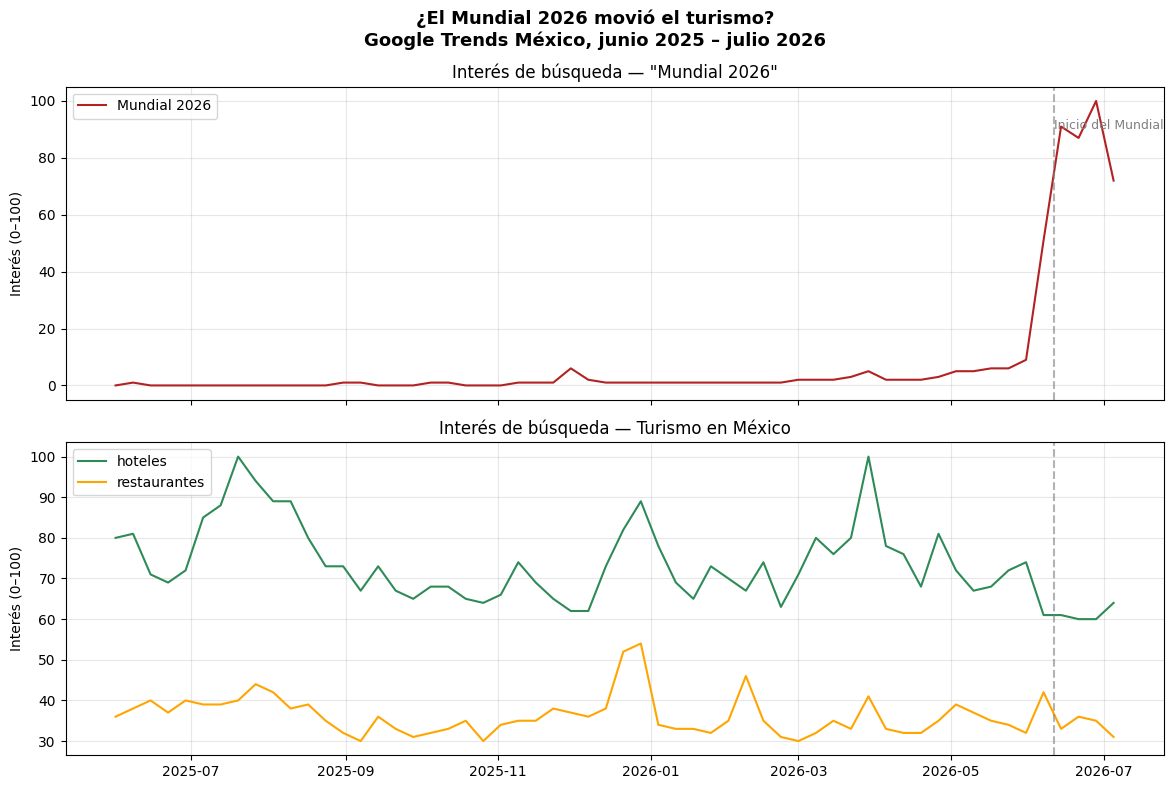

In [31]:
# sharex=True hace que los dos paneles compartan el eje x
# útil para series de tiempo que queremos comparar verticalmente
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ── Panel superior: el evento ─────────────────────────────────────────────────
axes[0].plot(df_trends.index, df_trends['Mundial 2026'],
             color='firebrick', linewidth=1.5, label='Mundial 2026')

# axvline dibuja una línea vertical en una fecha específica
axes[0].axvline(INICIO_MUNDIAL, color='gray', linestyle='--', alpha=0.6)
axes[0].annotate('Inicio del Mundial', xy=(INICIO_MUNDIAL, 90),
                 fontsize=9, color='gray')
axes[0].set_title('Interés de búsqueda — "Mundial 2026"', fontsize=12)
axes[0].set_ylabel('Interés (0–100)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Panel inferior: turismo ───────────────────────────────────────────────────
axes[1].plot(df_trends.index, df_trends['hoteles'],
             color='seagreen', linewidth=1.5, label='hoteles')
axes[1].plot(df_trends.index, df_trends['restaurantes'],
             color='orange', linewidth=1.5, label='restaurantes')

axes[1].axvline(INICIO_MUNDIAL, color='gray', linestyle='--', alpha=0.6)
axes[1].set_title('Interés de búsqueda — Turismo en México', fontsize=12)
axes[1].set_ylabel('Interés (0–100)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('¿El Mundial 2026 movió el turismo?\nGoogle Trends México, junio 2025 – julio 2026',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
# Comparamos el promedio antes y durante el Mundial
antes   = df_trends[df_trends.index <  INICIO_MUNDIAL]
durante = df_trends[df_trends.index >= INICIO_MUNDIAL]

print("Cambio en interés promedio: antes vs durante el Mundial\n")
print(f"{'Término':<30} {'Antes':>8} {'Durante':>8} {'Cambio':>8}")
print("-" * 58)

for col in df_trends.columns:
    prom_antes   = antes[col].mean()
    prom_durante = durante[col].mean()
    # cambio porcentual: (nuevo - viejo) / viejo * 100
    cambio       = (prom_durante - prom_antes) / prom_antes * 100
    print(f"{col:<30} {prom_antes:>8.1f} {prom_durante:>8.1f} {cambio:>+7.1f}%")

Cambio en interés promedio: antes vs durante el Mundial

Término                           Antes  Durante   Cambio
----------------------------------------------------------
Mundial 2026                        2.4     87.5 +3479.5%
hoteles                            74.2     61.2   -17.4%
restaurantes                       36.3     33.8    -7.0%
